## Simulation Code for thermal spreading of PCBA Board ##

Author: Jiong Chen

Date: February 11, 2025

Copyright: © 2025 Jiong Chen. All rights reserved.

Reference:
    1. Jain, Ankur. "Thermal spreading resistance from an isothermal source into a finite-thickness body." International Journal of Heat and Mass Transfer 220 (2024): 124946.

**1. SPREADING RESISTANCE IN COMPOUND RECTANGULAR CHANNELS**

*Testing Board Information*

- 40mm x 40mm board
- chip at center of the board with 5W power generation

*Boundary Condition*

- Top chip surface natural convection, 10W/m^2-K htc. (PCB board natural convection ignored)
- Bottom PCBA surface fixed temperature at 55C.
- k_z of PCBA (vertical direction) ~ 15W/m-K
- k of Chip ~ 15W/m-K


In [ ]:
# Implementation of "Reference 1"
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# Geometry Information
t_chip = 1e-3           # chip thickness, [m]
t_board = 10e-3         # PCBA board thickness, [m]
t_sink = 50e-3          # sink thickness, [m] guessing values

Q_chip = 5              # chip power, [W]
k_PCBA_z = 15           # PCBA board thermal conductivity along z-aixs, [W/m-K]
k_chip = 15             # chip thermal conductivity, [W/m-K]
T_BC = 55               # bottom surface boundary condition, [C]
T_env = 55              # environmental temperature, [C]230232
h_air = 10              # air side htc, [W/m^2-K]

L_PCBA = 400e-3;         # length of the board, [m]
W_PCBA = 400e-3;         # width of the board, [m]

L_chip = 10e-3;         # length of the chip, [m]
W_chip = 10e-3;         # width of the chip, [m]


# [Some const here...]
N = 150
Nz = 20
Nx = 20
A = L_PCBA/2
a = L_chip/2
t = t_sink
k = 120 # [W/m-K], casted-aluminum
h_sink = 100 # [W/m^2-K]

# delta = x / A
# eta = z / A
a_bar = a / A
t_bar = t / A
Bi_max = 1e6
Bi_sink = h_sink * A / k

# Generate LHX

#       Generate lam_n
lam_n = np.arange(0,N+1) * np.pi
lam_m = lam_n

# temporary input to compare with paper
a_bar = 0.1; t_bar = 0.4; Bi_sink = 2
A = 2; t = 0.4*A; a = 0.1*A

# calculate p0 and pn
p0 = -(t_bar + 1 / Bi_sink)
pn = -(Bi_sink*np.cosh(lam_n[1:]*t_bar) + lam_n[1:]*np.sinh(lam_n[1:]*t_bar)) / (Bi_sink*np.sinh(lam_n[1:]*t_bar) + lam_n[1:]*np.cosh(lam_n[1:]*t_bar))
p = np.hstack(([p0], pn))  # Using hstack to combine scalar and array

#       Initialize A
A_mat = np.zeros((N+1, N+1))
b = np.zeros(N+1)

#       Compute elements in A
# Eq.18, m = 0
A_mat[0,0] = 1/Bi_max - p[0] * a_bar
for n in range(1,N+1):
    A_mat[0,n] = -np.sin(lam_n[n] * a_bar) / lam_n[n]
b[0] = -a_bar

# Eq.19, m from 1 to N
for m in range(1,N+1):
    A_mat[m,0] = -p[0] * np.sin(lam_m[m]*a_bar) / lam_m[m]
    for n in range(1,1+N):
        if m==n:
            A_mat[m,n] = (lam_m[m]*p[m]/(2*Bi_max) - a_bar/2 - np.sin(2*lam_m[m]*a_bar)/(4*lam_m[m]))
        else:
            A_mat[m,n] = -(lam_n[n]*np.sin(lam_n[n]*a_bar)*np.cos(lam_m[m]*a_bar) - lam_m[m]*np.cos(lam_n[n]*a_bar)*np.sin(lam_m[m]*a_bar))/(lam_n[n]**2 - lam_m[m]**2)
    b[m] = -np.sin(lam_m[m]*a_bar) / lam_m[m]

#       Solve Ax=b
C = la.solve(A_mat, b)
print(np.allclose(np.dot(A_mat,C),b))

#       Calculate theta (temperature difference)

def cal_theta(xi, eta):
    theta_value = C[0]*(eta + p[0])
    for n in range(1,N+1):
        theta_value += C[n]*np.cos(lam_n[n]*xi) * (np.cosh(lam_n[n]*eta) + p[n]*np.sinh(lam_n[n]*eta))
    return theta_value

z = np.arange(0,t,t/Nz)
x = np.arange(0,A,A/Nx)
eta = z/A
xi = x/A
theta_dist = np.zeros((Nx, Nz))
for nx in range(Nx):
    for nz in range(Nz):
        theta_dist[nx, nz] = cal_theta(xi[nx],eta[nz])

True


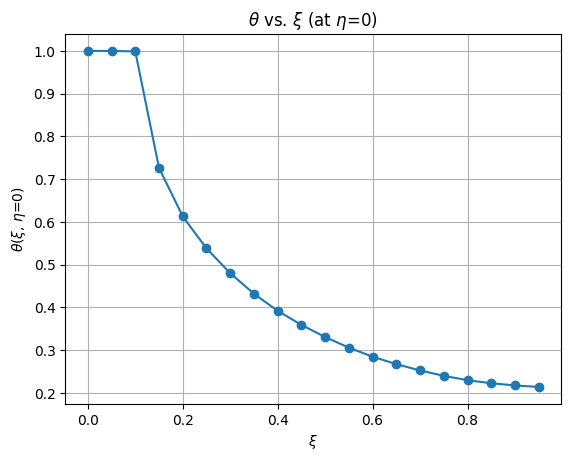

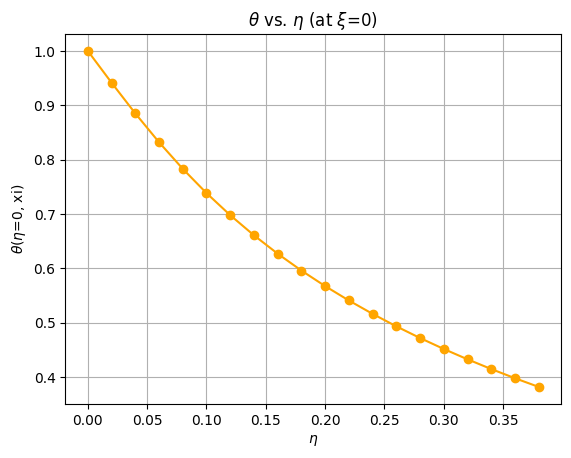

In [2]:
# Plot for (0, eta): fix xi=0, vary eta
plt.figure()
plt.plot(xi, theta_dist[:, 0], marker='o')
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\theta$($\xi$, $\eta$=0)')
plt.title(r'$\theta$ vs. $\xi$ (at $\eta$=0)')
plt.grid(True)

# Plot for (xi, 0): fix eta=0, vary xi
plt.figure()
plt.plot(eta, theta_dist[0, :], marker='o', color='orange')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\theta$($\eta$=0, xi)')
plt.title(r'$\theta$ vs. $\eta$ (at $\xi$=0)')
plt.grid(True)

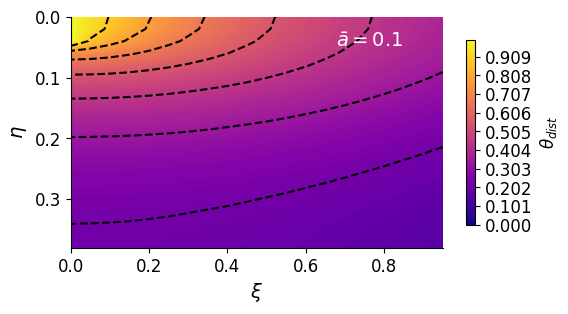

In [6]:
# Create figure
fig, ax = plt.subplots(figsize=(6, 3))  # Set aspect ratio similar to your image

# Filled contour plot (smooth shading)
contourf = ax.contourf(xi, eta, theta_dist, levels=np.linspace(0, 1, 100), cmap='plasma', vmin=0, vmax=1)

# Contour lines (dashed)
contour = ax.contour(xi, eta, theta_dist, levels=np.linspace(0, 1, 10), colors='black', linestyles='dashed')

# Labels and formatting
ax.set_xlabel(r'$\xi$', fontsize=14)
ax.set_ylabel(r'$\eta$', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

# **Invert y-axis to move origin to top-left**
ax.invert_yaxis()

# Add a label at the **bottom right** corner
ax.text(0.85, 0.05, r'$\bar{a} = 0.1$', fontsize=14, color='white', ha='right')

# Remove top and right borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add colorbar
cbar = fig.colorbar(contourf, ax=ax, orientation='vertical', shrink=0.8)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r'$\theta_{dist}$', fontsize=12)  # Label the colorbar

# Show plot
plt.show()

In [124]:
C.shape, N

((201,), 200)

In [132]:
#       Generate lam_n
lam_n = np.arange(0,N+1) * np.pi
lam_m = lam_n

# temporary input to compare with paper
a_bar = 0.1; t_bar = 0.4; Bi_sink = 2
A = 2; t = 0.4*A; a = 0.1*A

# calculate p0 and pn
p0 = -(t_bar + 1 / Bi_sink)
pn = -(Bi_sink * np.cosh(lam_n[1:] * t_bar) + lam_n[1:] * np.sinh(lam_n[1:] * t_bar)) / (Bi_sink * np.sinh(lam_n[1:] * t_bar) + lam_n[1:] * np.cosh(lam_n[1:] * t_bar))
p = np.hstack(([p0], pn))  # Using hstack to combine scalar and array


In [135]:
p[1] - pn[0]

np.float64(0.0)